#### T5 
- Use either clustering algorithm discussed on the data set moons_data.csv, which can be downloaded from Canvas.
- What can you conclude about the results of the clustering algorithm?


#### Goal
Use either K-Means or Mean Shift to cluster the dataset moons_data.csv and analyze the result.



          0         1
0  0.391849  0.904123
1 -0.095541  0.458993
2  0.111626  0.099991
3  1.761204 -0.124941
4  1.907206 -0.099912 



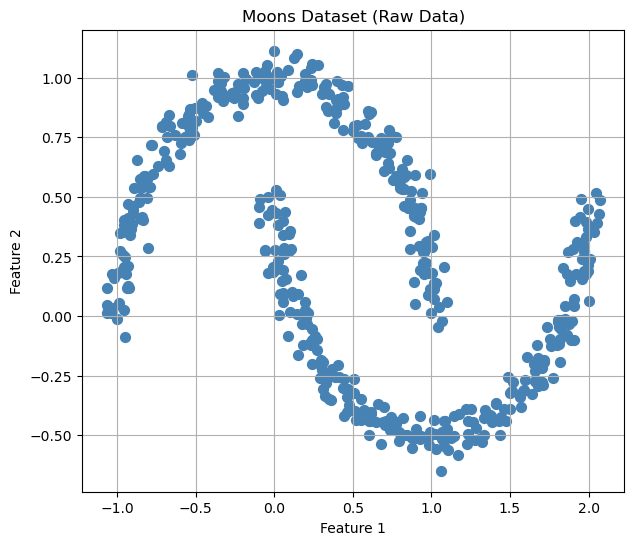

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MeanShift

# --- READ DATA ---
df = pd.read_csv('moons_data.csv', index_col=0)
print(df.head(), '\n')

# --- SELECT FEATURES ---
X = df.values

# --- VISUALIZE RAW DATA ---
plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], s=50, color='steelblue')
plt.title('Moons Dataset (Raw Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()


#### Option 1: K-Means Clustering

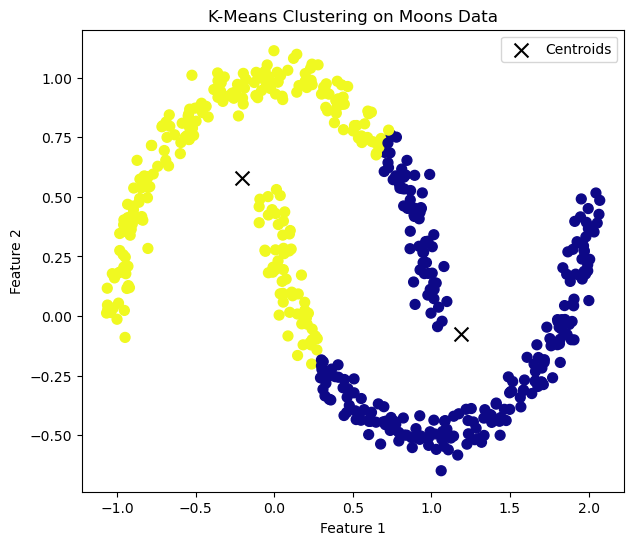

In [3]:
kmeans = KMeans(n_clusters=2, n_init='auto', random_state=42)
kmeans.fit(X)

y_kmeans = kmeans.predict(X)

# --- PLOT RESULTS ---
plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], c=y_kmeans, s=50, cmap='plasma')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=100, c='black', marker='x', label='Centroids')
plt.title('K-Means Clustering on Moons Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


#### K-Means Result Analysis
- K-Means tries to divide data into spherical (convex) regions.
- The “moons” are non-convex, so K-Means fails to separate them correctly.
- The boundary will likely cut through the curved clusters, producing incorrect classification.

#### 🧩 Conclusion (K-Means):
- K-Means does not handle non-linear cluster boundaries well.
- It works best for spherical clusters, not moon-shaped or concentric ones.

#### Option 2: Mean Shift Clustering

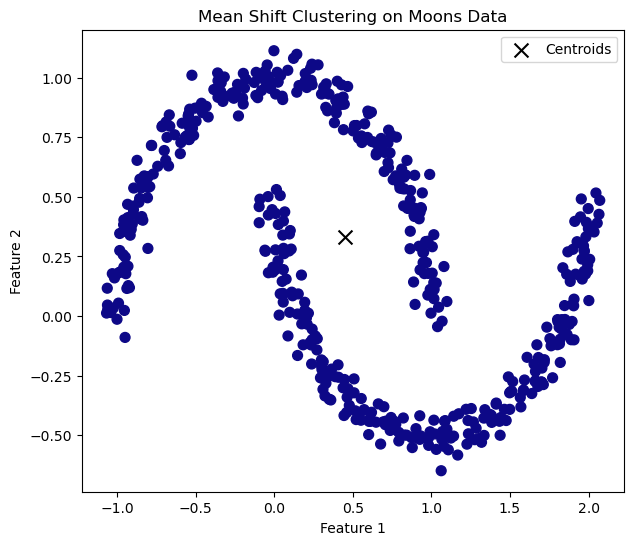

MeanShift found 1 clusters.


In [5]:
ms = MeanShift()
ms.fit(X)
y_ms = ms.labels_
centers_ms = ms.cluster_centers_

# --- PLOT RESULTS ---
plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], c=y_ms, s=50, cmap='plasma')
plt.scatter(centers_ms[:,0], centers_ms[:,1],
            s=100, c='black', marker='x', label='Centroids')
plt.title('Mean Shift Clustering on Moons Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

print(f"MeanShift found {len(np.unique(y_ms))} clusters.")


#### Mean Shift Result Analysis
- Mean Shift does not assume spherical clusters.
- It can adapt to the density of points.
- On the moons dataset, it usually identifies the two crescent clusters correctly, even though they’re curved.

#### 🧩 Conclusion (Mean Shift):
- Mean Shift performs better than K-Means because it’s a density-based algorithm and can detect clusters of arbitrary shapes.
- It successfully captures the moon-shaped patterns in the data.

#### Lecturers COnclusion

We can see that both algorithms failed to successfully cluster the moons dataset. The challenge with this dataset is that the moons data is not linearly separable data. K-Means expects clusters to have a spherical, "blob like", shape and struggles here because the two crescent shaped cluster are intertwined. Thinking about K-Means works, using centroids and the distance from centroids to custer points, we can see why this method would struggle with data such as this.

Mean Shift has also failed here, again because of the structure of these clusters. Recall, that Mean Shift is a density based algorithm that looks for high density regions in the data to identify clusters. The moons data causes issues because there are areas of high density caused by overlap of the two clusters. In the plot above we can see that the middle of this data, where the inner tips of the data crescents cause the highest density in data. Experiment with adjusting the bandwidth and see what you find.